In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import h5py as h5 
from astropy import units as u
from astropy import constants as c

import scipy

pd.options.display.max_columns = None

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib
from matplotlib.ticker import LogLocator, AutoMinorLocator, MultipleLocator
rcParams['font.family'] = 'serif'
rcParams["mathtext.fontset"] = 'stix'
rcParams["font.size"] = 13

%config InlineBackend.figure_format='retina' # very useful command for high-res images

colorPalette = {'red': "#E64D4E",
                'orange': "#EE9063",
                'yellow': "#FFDD7B",
                'green': "#77AC54",
                'blue': "#0B92B1",
                'violet': "#665191",
                'gray': "#B4B4B4"
}

In [3]:
PlotDir = 'paper_plots/'


## Appendix A.1 Equilibrium Tides

COMPAS -n 1 --random-seed 0  --output-path sim_data --output-container equilibrium_comparison_ogilvie_barker --initial-mass-1 1.0 --mass-ratio 1.0  --orbital-period 0.7 --eccentricity 0.0  --metallicity 0.02 --tides-prescription KAPIL2026 --maximum-number-timestep-iterations 99999

In [15]:
DataPath = 'sim_data/equilibrium_comparison_ogilvie_barker'

df_sanity = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity = df_sanity.rename(columns=lambda x: x.strip())

In [16]:
rc = df_sanity["R1_core"].values * u.R_sun              # Rsol
R = df_sanity["R1"].values * u.R_sun                    # Rsol
Renv = df_sanity["R1_conv_env_extent"].values * u.R_sun # Rsol
Rint = R - Renv

L = df_sanity["Lum_1"].values * u.L_sun                 # Lsol

M = df_sanity["M1"].values * u.M_sun                    # Msol
Mc = df_sanity["M1_core"].values * u.M_sun              # Msol
Menv = df_sanity["M1_conv_env"].values * u.M_sun        # Msol

M2 = df_sanity["M2"].values * u.M_sun                   # Msol
I1 = df_sanity["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv = df_sanity["tau_conv1"].values * u.yr                # yr


omega_orb = df_sanity["Omega_before"].values / u.yr     # 1/yr
omega_spin = df_sanity["Omega1_before"].values / u.yr   # 1/yr
sma = df_sanity["SemiMajorAxis_before"].values * u.AU   # AU
ecc = df_sanity["ecc"].values                           # 1

Imk10 = df_sanity["ImK10_1"].values
Imk12 = df_sanity["ImK12_1"].values
Imk22 = df_sanity["ImK22_1"].values
Imk32 = df_sanity["ImK32_1"].values

Imk10_dyn = df_sanity["ImK10_1_dyn"].values
Imk12_dyn = df_sanity["ImK12_1_dyn"].values
Imk22_dyn = df_sanity["ImK22_1_dyn"].values
Imk32_dyn = df_sanity["ImK32_1_dyn"].values

Imk10_eq = df_sanity["ImK10_1_eq"].values
Imk12_eq = df_sanity["ImK12_1_eq"].values
Imk22_eq = df_sanity["ImK22_1_eq"].values
Imk32_eq = df_sanity["ImK32_1_eq"].values

dadt = df_sanity["dadt1"].values
dOmegadt = df_sanity["dOmegadt1"].values
dedt = df_sanity["dedt1"].values


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time = df_sanity["Time"].values * 1e6 * u.yr          # yr
st1 = df_sanity["StellarType_1"].values

rc_AU = df_sanity["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU = df_sanity["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU = df_sanity["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU = R_AU - Renv_AU                  
Mint = M - Mc - Menv     

$$ \omega_c = 1 / t_c $$
$$ \omega_t = n \omega - m \Omega $$

$$ \rho_c \approx \frac{M_{\rm conv}}{\frac{4}{3} \pi (R^3 - R_{\rm conv}^3)} $$
$$ l_c \approx R_{\rm conv} $$



In [18]:
omega_c = 1/tau_conv
omega_t = np.abs(2*(omega_orb - omega_spin))
period_t = (2 * np.pi / omega_t).to(u.yr)
rho_c = Menv / (4 * np.pi * (R_AU**3 - Rint_AU**3) / 3)
l_c = Renv_AU / 2
v_c = l_c / tau_conv

/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: divide by zero encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


In [20]:
# From Zahn 1989, before Eq (1)
nu_mlt = (1/3) * l_c * v_c
nu_mlt = np.nan_to_num(nu_mlt, nan=0.0)

# From Zahn 1989, Eq (9)
nu_reduced_z77 = (1/3) * v_c * l_c * np.minimum(1, (v_c * period_t/ (2 * l_c)))
nu_reduced_z77 = np.nan_to_num(nu_reduced_z77, nan=0.0)

# From Zahn 1989, Eq (10)
nu_reduced_g77 = (1/3) * v_c * l_c * np.minimum(1, (v_c * period_t/ (2 * np.pi * l_c))**2)
nu_reduced_g77 = np.nan_to_num(nu_reduced_g77, nan=0.0)

In [21]:
A2 = (G_AU_Msol_yr * M2 / sma**3)**2

D_nu_mlt = (28/3) * omega_t**2 * (M2/M)**2 * (R_AU**9 - Rint_AU**9) * rho_c * nu_mlt / sma**6
imk22_eq_manual_mlt = np.sign(omega_orb - omega_spin) * (3./2.) * (16 * np.pi * G_AU_Msol_yr) * D_nu_mlt / (3 * 5 * R_AU**5 * A2 * np.abs(omega_t))

D_nu_z77 = (28/3) * omega_t**2 * (M2/M)**2 * (R_AU**9 - Rint_AU**9) * rho_c * nu_reduced_z77 / sma**6
imk22_eq_manual_z77 = np.sign(omega_orb - omega_spin) * (3./2.) * (16 * np.pi * G_AU_Msol_yr) * D_nu_z77 / (3 * 5 * R_AU**5 * A2 * np.abs(omega_t))

D_nu_g77 = (28/3) * omega_t**2 * (M2/M)**2 * (R_AU**9 - Rint_AU**9) * rho_c * nu_reduced_g77 / sma**6
imk22_eq_manual_g77 = np.sign(omega_orb - omega_spin) * (3./2.) * (16 * np.pi * G_AU_Msol_yr) * D_nu_g77 / (3 * 5 * R_AU**5 * A2 * np.abs(omega_t))


/opt/anaconda3/envs/tides_compas/lib/python3.11/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in divide
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


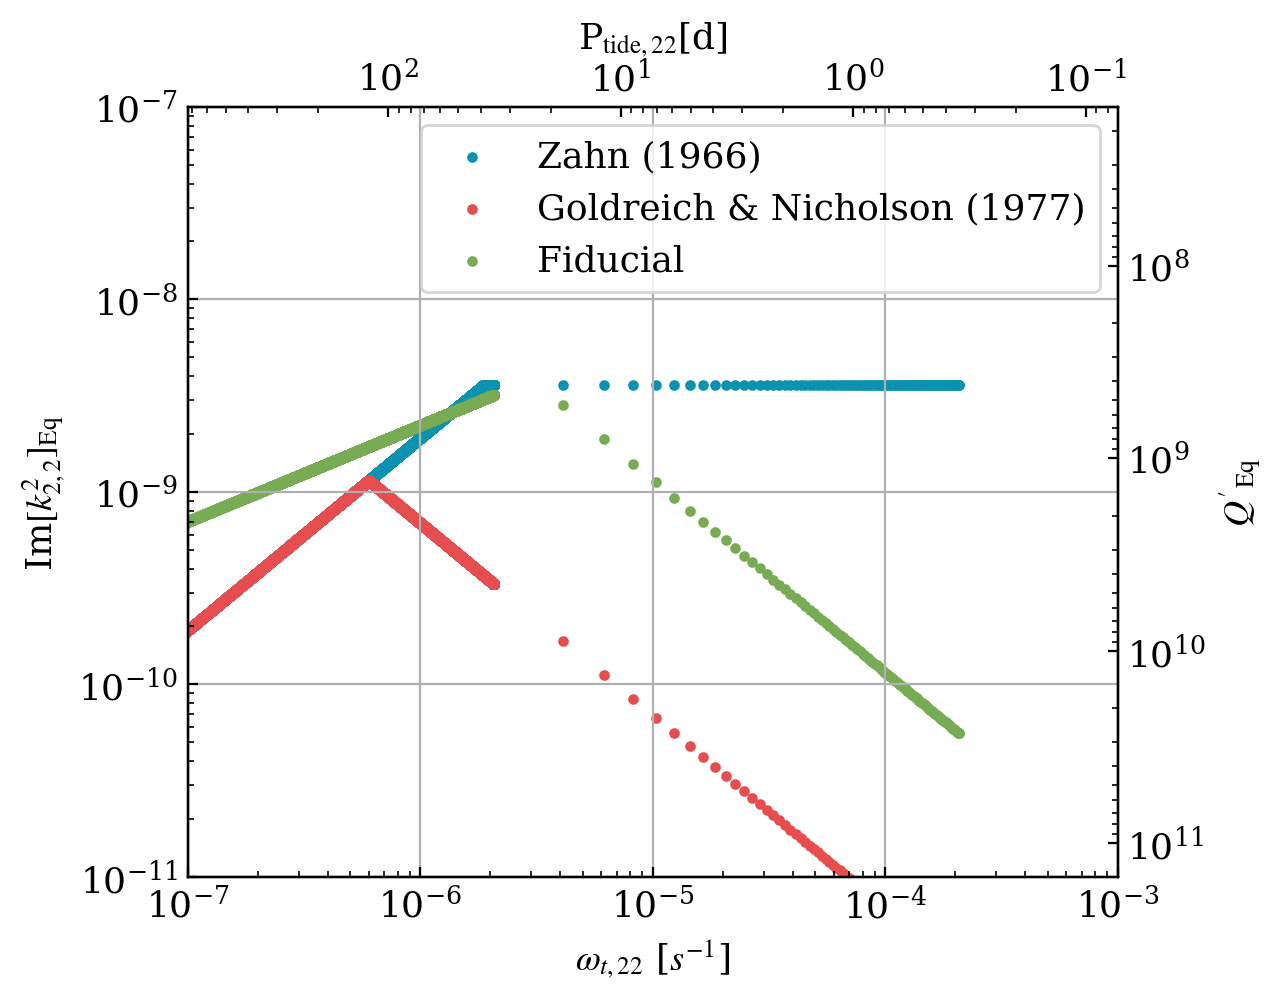

In [22]:
# Ogilvie (2014) Fig 5 Manual calculations  

imk22_min = 1e-11
imk22_max = 1e-7

omega22_min = 1e-7 * 1/u.s
omega22_max = 1e-3 * 1/u.s


mask = (M.value >= 0.9)
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

# plt.scatter(omega_t.to(1/u.s), imk22_eq_manual_mlt)
ax.scatter(omega_t.to(1/u.s)[mask], imk22_eq_manual_z77[mask], c=colorPalette['blue'], s=8, label='Zahn (1966)')
ax.scatter(omega_t.to(1/u.s)[mask], imk22_eq_manual_g77[mask], c=colorPalette['red'], s=8, label='Goldreich & Nicholson (1977)')
ax.scatter(omega_t.to(1/u.s)[mask], np.abs(Imk22_eq)[mask], c=colorPalette['green'], s=8, label='Fiducial')

ax.set_ylabel("Im$[k_{2,2}^2 ]_{\\rm Eq}$")
ax.set_xlabel("$\omega_{t, 22}$ [$s^{-1}$]")

ax.set_xlim(omega22_min.value, omega22_max.value)
ax.set_ylim(imk22_min, imk22_max)
ax.grid()
ax.legend()


ax.set_yscale('log')
ax.set_xscale('log')
ax.tick_params(axis='both', which='both', direction='in')


ax2 = ax.twinx() 
ax2.set_ylim(3/(2*imk22_min), 3/(2*imk22_max))
ax2.set_yscale('log')
ax2.set_ylabel("$Q'_{\\rm Eq}$")
ax2.tick_params(axis='both', which='both', direction='in', bottom=False)


ax3=ax.twiny()
ax3.set_xscale('log')
ax3.set_xlim(((2*np.pi)/omega22_min).to(u.day).value, ((2*np.pi)/omega22_max).to(u.day).value)
ax3.set_xlabel("P$_{\\rm tide, 22}$[d]")
ax3.tick_params(axis='both', which='both', direction='in', bottom=False)

plt.savefig(PlotDir+"/ogilvie_comparison_freq_dependence.png", dpi=300, bbox_inches='tight')

plt.show()


# Appendix A.2 Dynamical Tides

COMPAS -n 1 --output-path sim_data --output-container dynamical_comparison_ahuir --initial-mass-1 1.0 --initial-mass-2 0.0009 --minimum-secondary-mass 0.0001 --orbital-period 1 --eccentricity 0.0 --tides-prescription NONE --timestep-multiplier 0.1


In [23]:
DataPath = 'sim_data/dynamical_comparison_ahuir'
df_sanity = pd.read_csv(DataPath+'/sanity_checks.csv')
df_sanity = df_sanity.rename(columns=lambda x: x.strip())
pd.options.display.max_columns = None
df_sanity.iloc[:]

,SEED,Time,Dt,StellarType_1,StellarType_2,J_before,J_after,Jorb_before,Jorb_after,J1_before,J1_after,J2_before,J2_after,Omega_before,Omega,Omega1_before,Omega1,Omega2_before,Omega2,ecc_before,ecc,M1,R1,I1_before,I1_after,M2,R2,I2_before,I2_after,SemiMajorAxis_before,SemiMajorAxis_after,ImK10_1,ImK10_2,ImK12_1,ImK12_2,ImK22_1,ImK22_2,ImK32_1,ImK32_2,ImK10_1_dyn,ImK10_2_dyn,ImK12_1_dyn,ImK12_2_dyn,ImK22_1_dyn,ImK22_2_dyn,ImK32_1_dyn,ImK32_2_dyn,ImK10_1_eq,ImK10_2_eq,ImK12_1_eq,ImK12_2_eq,ImK22_1_eq,ImK22_2_eq,ImK32_1_eq,ImK32_2_eq,M1_core,R1_core,M2_core,R2_core,M1_conv_env,M1_conv_env_max,M2_conv_env,M2_conv_env_max,R1_conv_env_extent,R2_conv_env_extent,tau_conv1,tau_conv2,Lum_1,Lum_2,Temp_1,Temp_2,dadt1,dadt2,dOmegadt1,dOmegadt2,dedt1,dedt2,DaDt_tidal,DeDt_tidal,DOmegaDt_tidal,suggested_dt,dM1_winds,dM2_winds,dM1_MT,dM2_MT,ImK10_Zahn_Equilibrium1,ImK10_Zahn_Equilibrium2,ImK12_Zahn_Equilibrium1,ImK12_Zahn_Equilibrium2,ImK22_Zahn_Equilibrium1,ImK22_Zahn_Equilibrium2,ImK32_Zahn_Equilibrium1,ImK32_Zahn_Equilibrium2,ImK10_Zahn_Dynamical1,ImK10_Zahn_Dynamical2,ImK12_Zahn_Dynamical1,ImK12_Zahn_Dynamical2,ImK22_Zahn_Dynamical1,ImK22_Zahn_Dynamical2,ImK32_Zahn_Dynamical1,ImK32_Zahn_Dynamical2,DSemiMajorAxis1Dt_tidal_Zahn,DSemiMajorAxis2Dt_tidal_Zahn,DEccentricity1Dt_tidal_Zahn,DEccentricity2Dt_tidal_Zahn,DOmega1Dt_tidal_Zahn,DOmega2Dt_tidal_Zahn
0,1770931584,0.000000,0.009994,1,0,0.000791,0.000791,0.000791,0.000791,0,0,0,0,2294.93,2294.93,0,0,0,0,0,0,1.000000,0.894082,0.000002,0.000002,0.0009,0.000004,2.552560e-20,2.552560e-20,0.019577,0.019577,1.367890e-05,1.078150e-22,1.367890e-05,1.078150e-22,8.685430e-05,5.390730e-23,2.560750e-04,3.593820e-23,0.000014,0,0.000014,0,0.000087,0,0.000256,0,1.859770e-10,1.078150e-22,1.859770e-10,1.078150e-22,9.298830e-11,5.390730e-23,6.199220e-11,3.593820e-23,0.190789,0.000000,0.000923,0,0.027006,0.027006,0.0009,0.0009,0.176528,0.000004,0.050056,0.204116,0.817982,1.853240e-14,1.005770,0.193887,-4.553540e-09,-3.803490e-48,5.320220e-05,3.009780e-30,0,0,0.042992,inf,0.431361,0.042992,0.000000,0,0,0,3.211540e-10,1.294900e-23,3.211540e-10,1.294900e-23,6.423080e-10,2.589790e-23,9.634620e-10,3.884690e-23,3.243500e-12,2.249270e-38,3.243500e-12,2.249270e-38,2.059490e-11,1.428200e-37,6.072070e-11,4.210810e-37,-3.475420e-14,-1.827260e-48,0,0,4.060580e-10,1.445950e-30
1,1770931584,0.009994,9.993640,1,0,0.000791,0.000791,0.000791,0.000791,0,0,0,0,2294.93,2294.93,0,0,0,0,0,0,1.000000,0.894083,0.000002,0.000002,0.0009,0.000004,2.552560e-20,2.552560e-20,0.019577,0.019577,1.367890e-05,1.078150e-22,1.367890e-05,1.078150e-22,8.685460e-05,5.390730e-23,2.560760e-04,3.593820e-23,0.000014,0,0.000014,0,0.000087,0,0.000256,0,1.859770e-10,1.078150e-22,1.859770e-10,1.078150e-22,9.298830e-11,5.390730e-23,6.199220e-11,3.593820e-23,0.190789,0.000000,0.000923,0,0.027006,0.027006,0.0009,0.0009,0.176528,0.000004,0.050056,0.204116,0.817982,1.853240e-14,1.005770,0.193887,-4.553560e-09,-3.803490e-48,5.320240e-05,3.009780e-30,0,0,0.042992,inf,0.431359,0.042992,0.000000,0,0,0,3.211540e-10,1.294900e-23,3.211540e-10,1.294900e-23,6.423090e-10,2.589790e-23,9.634630e-10,3.884690e-23,3.243500e-12,2.249270e-38,3.243500e-12,2.249270e-38,2.059490e-11,1.428200e-37,6.072080e-11,4.210810e-37,-3.475430e-14,-1.827260e-48,0,0,4.060590e-10,1.445950e-30
2,1770931584,10.003600,9.993640,1,0,0.000791,0.000791,0.000791,0.000791,0,0,0,0,2294.93,2294.93,0,0,0,0,0,0,1.000000,0.894332,0.000002,0.000002,0.0009,0.000004,2.552560e-20,2.552560e-20,0.019577,0.019577,1.372140e-05,1.078150e-22,1.372140e-05,1.078150e-22,8.712410e-05,5.390730e-23,2.568710e-04,3.593820e-23,0.000014,0,0.000014,0,0.000087,0,0.000257,0,1.860590e-10,1.078150e-22,1.860590e-10,1.078150e-22,9.302960e-11,5.390730e-23,6.201970e-11,3.593820e-23,0.190713,0.000000,0.000923,0,0.026999,0.027006,0.0009,0.0009,0.176484,0.000004,0.050045,0.204116,0.818409,1.853240e-14,1.005760,0.193887,-4.574060e-09,-3.803490e-48,5.341210e-05,3.009780e-30,0,0,0.042799,inf,0.429665,0.042799,0.000000,0,0,0,3.215630e-10,1.29490

In [24]:
# From the perspective of Star 1
rc = df_sanity["R1_core"].values * u.R_sun              # Rsol
R = df_sanity["R1"].values * u.R_sun                    # Rsol
Renv = df_sanity["R1_conv_env_extent"].values * u.R_sun # Rsol

L = df_sanity["Lum_1"].values * u.L_sun                 # Lsol

M = df_sanity["M1"].values * u.M_sun                    # Msol
Mc = df_sanity["M1_core"].values * u.M_sun              # Msol
Menv = df_sanity["M1_conv_env"].values * u.M_sun        # Msol

M2 = df_sanity["M2"].values * u.M_sun                   # Msol
I1 = df_sanity["I1_before"].values * u.M_sun * u.AU**2  # Msol * AU^2

tau_conv = df_sanity["tau_conv1"].values * u.yr                # yr


omega_orb = df_sanity["Omega_before"].values / u.yr     # 1/yr
omega_spin = df_sanity["Omega1_before"].values / u.yr   # 1/yr
sma = df_sanity["SemiMajorAxis_before"].values * u.AU   # AU
ecc = df_sanity["ecc"].values                           # 1

Imk10 = df_sanity["ImK10_1"].values
Imk12 = df_sanity["ImK12_1"].values
Imk22 = df_sanity["ImK22_1"].values
Imk32 = df_sanity["ImK32_1"].values

Imk10_dyn = df_sanity["ImK10_1_dyn"].values
Imk12_dyn = df_sanity["ImK12_1_dyn"].values
Imk22_dyn = df_sanity["ImK22_1_dyn"].values
Imk32_dyn = df_sanity["ImK32_1_dyn"].values

Imk10_eq = df_sanity["ImK10_1_eq"].values
Imk12_eq = df_sanity["ImK12_1_eq"].values
Imk22_eq = df_sanity["ImK22_1_eq"].values
Imk32_eq = df_sanity["ImK32_1_eq"].values

dadt = df_sanity["dadt1"].values
dOmegadt = df_sanity["dOmegadt1"].values
dedt = df_sanity["dedt1"].values


G_AU_Msol_yr = c.G.to(u.AU**3 / u.M_sun / u.yr**2)
Time = df_sanity["Time"].values * 1e6 * u.yr          # yr
st1 = df_sanity["StellarType_1"].values

rc_AU = df_sanity["R1_core"].values * u.R_sun.to(u.AU) * u.AU  # AU
Renv_AU = df_sanity["R1_conv_env_extent"].values * u.R_sun.to(u.AU) * u.AU  # AU
R_AU = df_sanity["R1"].values * u.R_sun.to(u.AU) * u.AU        # AU
Rint_AU = R_AU - Renv_AU                  
Mint = M - Mc - Menv     

In [25]:
st_labels = ['MS_LT_0.7', 'MS_GT_0.7', 'HG', 'FGB', 'CHeB', 'EAGB', 'TPAGB', 'HeMS', 'HeHG', 'HeGB', 'HeWD', 'COWD', 'ONeWD', 'NS', 'BH', 'MR', 'CHE', '--', '--', 'None']

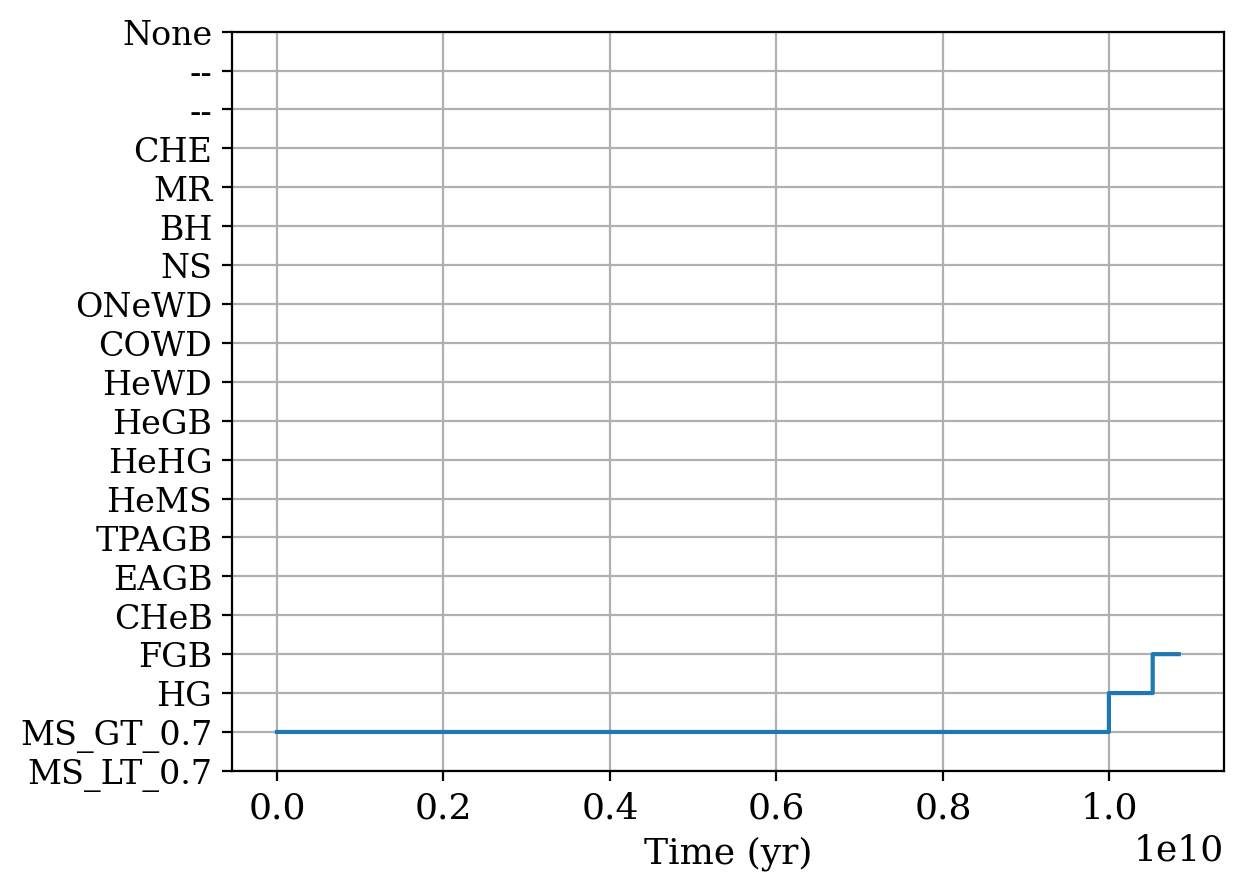

In [26]:
plt.plot(Time, st1)
y_ticks=np.linspace(0, 19, 20)
plt.yticks(y_ticks, st_labels, fontsize=12)

plt.xlabel('Time (yr)')
plt.grid()
plt.show()

### Ahuir+ 2021 Fig 9

In [27]:
Rint_AU = R_AU - Renv_AU                  
Mint = M - Mc - Menv     

Need to use the stellar rotation rate from Fig. 7. of Ahuir+ instead of the correct simulated spin

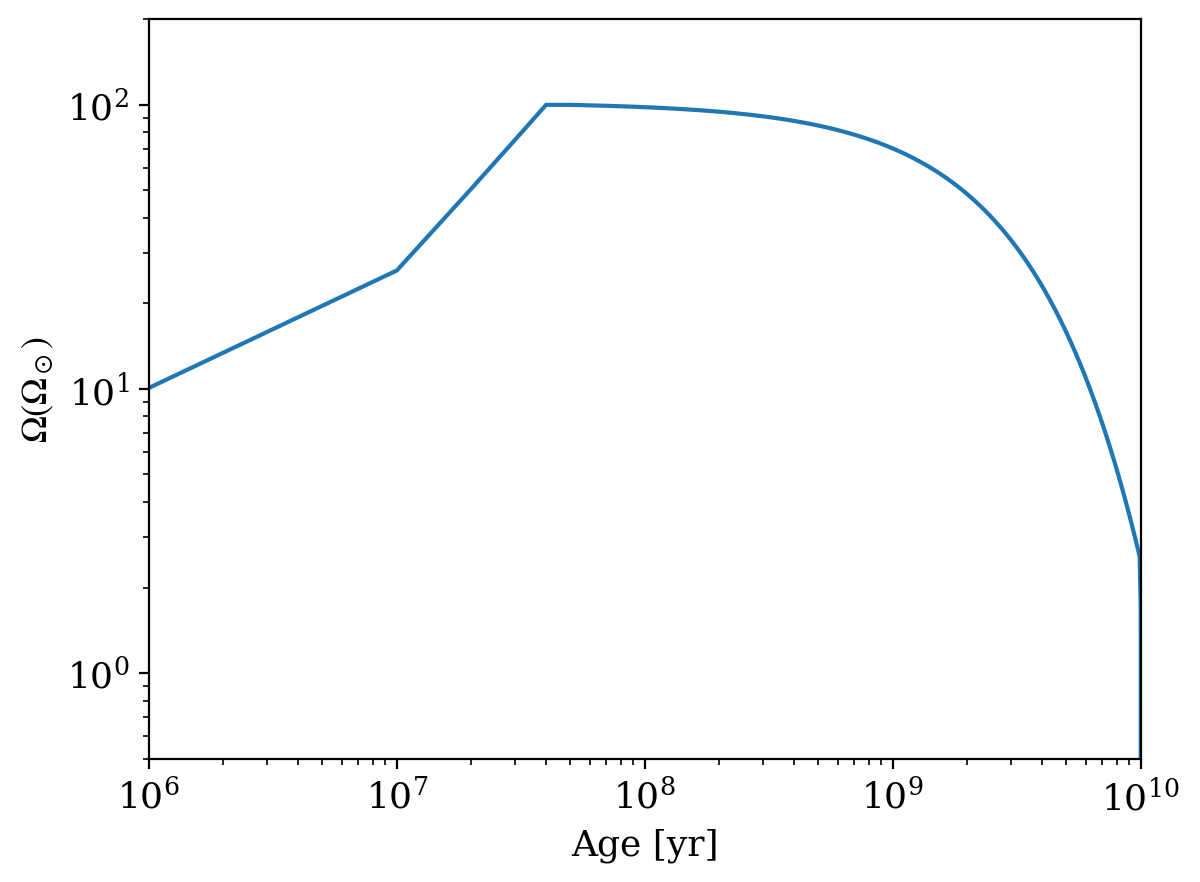

In [28]:
omega_sun_to_per_yr = (1/(27 *u.day)).to(1/u.yr)

spin_model = np.zeros(len(omega_spin))
start_idx = np.where(Time.value < 1e6)[0][-1]
low_idx = np.where(Time.value < 4e7)[0][-1]
end_idx = np.where(Time.value < 1e10)[0][-2]

spin_model[start_idx:low_idx+1] = np.linspace(1.5e0, 1e2, low_idx-start_idx+1)
spin_model[low_idx+1:end_idx+1] = np.geomspace(1e2, 1e0, end_idx-low_idx)
spin_model[0:start_idx] = 1e1

spin_model_yr = spin_model * omega_sun_to_per_yr

plt.plot(Time, spin_model)
plt.loglog()

plt.ylim(5e-1, 2e2)
plt.xlim(1e6, 1e10)

plt.ylabel("$\Omega (\Omega_\odot)$")
plt.xlabel("Age [yr]")
plt.show()

### Im[$k_2^2$], Gravity Waves, Radiative Zone

In [29]:
imk22_zahn = 0.1 * (2./3.) * (rc_AU/R_AU)**9 * (M/Mc)**(4./3.) * (2 * np.abs(omega_orb-spin_model_yr) * np.sqrt(R_AU**3 / (G_AU_Msol_yr * M)))**(8./3.)

dNlnr_cbrt = (G_AU_Msol_yr * Mint / (Rint_AU * (R_AU - Rint_AU)**2))**(1/3)
alpha = Rint_AU/R_AU
beta = Mint/M
rho_conv = Menv / (4 * np.pi * (R_AU**3 - Rint_AU**3))
rho_rad = Mint / (4 * np.pi * (Rint_AU**3 - rc_AU**3))
gamma = rho_conv / rho_rad
Epsilon = alpha**11 * (1-beta) * (1-gamma)**2 * (2*alpha/3 - 1)**2 / (beta**2 * (1-alpha**3) * (1-alpha)**2)
l=2
m=2
imk22_Ahuir = (3**(11/3) * scipy.special.gamma(1/3)**2 / (40*np.pi)) * (l*(l+1))**(-4/3) * np.abs((l*omega_orb)- (m*spin_model_yr))**(8/3) * (R_AU**3 / (G_AU_Msol_yr * M)) * Epsilon / dNlnr_cbrt
imk22_Ahuir[(Renv_AU <= 0) | (Menv <= 0)] = 0.0

imk22_gw = imk22_zahn + imk22_Ahuir

### Im[$k_2^2$], Inertial Waves, Convective Envelope

In [30]:
alpha = Rint_AU/R_AU
beta = Mint/M
gamma = alpha**3 * (1-beta) / (beta * (1 - alpha**3))

eps = spin_model_yr / omega_orb
b1 = (1 + 2*alpha + 3*alpha**2 + (3/2)*alpha**3)
b2 = 1 + ((1-gamma) / gamma) * alpha**3
b3 = 1 + (3*gamma/2) + ((5*alpha**3)/(2*gamma))*(1 + gamma/2 - (3*gamma**2)/2) - (9/4)*(1-gamma)*alpha**5
imk22_iw = (100 * np.pi / 63) * eps**2 * (alpha**5 / (1 - alpha**5)) * (1-gamma)**2 * (1-alpha)**4 * b1**2 * b2 * b3**(-2)

imk22_iw[((Renv_AU <= 0) & (Menv <= 0))] = 0.0
imk22_iw[np.isnan(imk22_iw)] = 0.0
imk22_iw

<Quantity [1.42919940e-05, 3.21569123e-07, 9.74404384e-05, ...,
           0.00000000e+00, 0.00000000e+00, 0.00000000e+00]>

### Im[$k_2^2$], Equilibrium, Convective Envelope

In [31]:
omega_c = 1/tau_conv
omega_t_22 = np.abs((2*omega_orb - 2*spin_model_yr))

rho_c = Menv / (4 * np.pi * (R_AU**3 - Rint_AU**3) / 3)
l_c = Renv_AU / 2
v_c = l_c / tau_conv

nu_mask_low = (omega_t_22/omega_c < 0.01)
nu_mask_mid = (omega_t_22/omega_c < 5) & (omega_t_22/omega_c > 0.01)
nu_mask_high = (omega_t_22/omega_c > 5)

nu_c = np.zeros(len(omega_c)) * u.AU**2 / u.yr

nu_c[nu_mask_low] = 5 * v_c[nu_mask_low] * l_c[nu_mask_low]
nu_c[nu_mask_mid] = 0.5 * v_c[nu_mask_mid] * l_c[nu_mask_mid] * (omega_t_22/omega_c)[nu_mask_mid]**(-0.5)
nu_c[nu_mask_high] = (25/np.sqrt(20)) * v_c[nu_mask_high] * l_c[nu_mask_high] * (omega_t_22/omega_c)[nu_mask_high]**(-2)


A2 = (G_AU_Msol_yr * M2 / sma**3)**2
D_nu22 = (28/3) * omega_t_22**2 * (M2/M)**2 * (R_AU**9 - Rint_AU**9) * rho_c * nu_c / sma**6

imk22_eq_manual = np.sign(omega_orb - spin_model_yr) * (3./2.) * (16 * np.pi * G_AU_Msol_yr) * D_nu22 / (3 * 5 * R_AU**5 * A2 * omega_t_22)


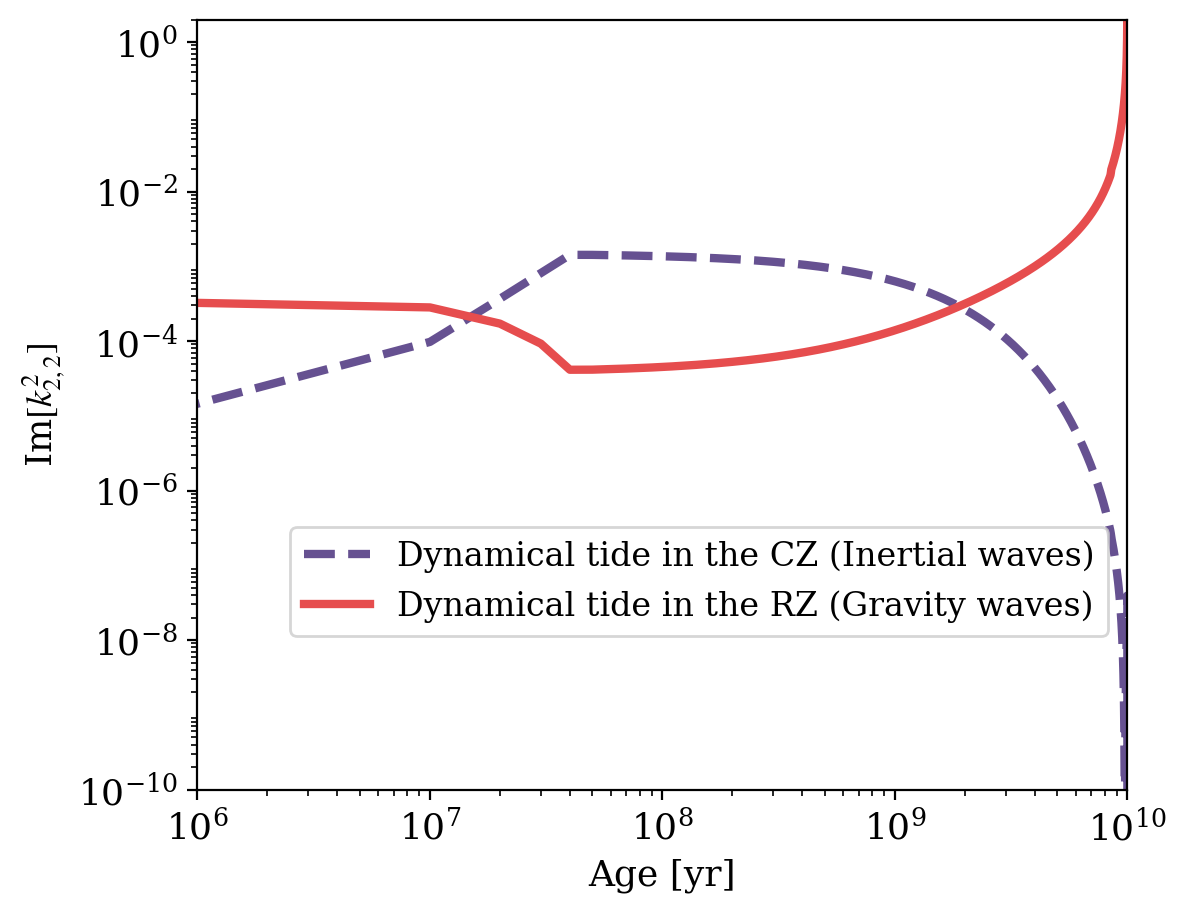

In [32]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6,5))

plt.plot(Time, imk22_iw, ls='--', lw=3, c=colorPalette['violet'], label="Dynamical tide in the CZ (Inertial waves)")
plt.plot(Time, imk22_gw, ls='-', lw=3, c=colorPalette['red'], label="Dynamical tide in the RZ (Gravity waves)")

plt.ylabel("Im$[k_{2,2}^2]$")
plt.xlabel("Age [yr]")

plt.xlim(1e6, 1e10)
plt.ylim(1e-10, 2e0)

plt.loglog()

ax.xaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))
ax.yaxis.set_minor_locator(LogLocator(numticks=999, subs="auto"))

plt.legend(fontsize=12, loc=(0.1, 0.2))
plt.savefig(PlotDir+'/ahuir_comparison.pdf', dpi=300, bbox_inches='tight')
plt.show()